In [34]:
import pandas as pd
import numpy as np

import os
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as st

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint

import warnings

warnings.filterwarnings("ignore")

os.makedirs('images', exist_ok=True)

In [35]:
df = pd.read_csv("marketing_campaign_large.csv")

In [36]:
df.head()

,Date,Facebook_Ad_Campaign,Facebook_Ad_Views,Facebook_Ad_Clicks,Facebook_Ad_Conversions,Cost_Per_Facebook_Ad,AdWords_Ad_Campaign,AdWords_Ad_Views,AdWords_Ad_Clicks,AdWords_Ad_Conversions,Cost_Per_AdWords_Ad,Facebook_CTR,Facebook_Conversion_Rate,Facebook_CPC,AdWords_CTR,AdWords_Conversion_Rate,AdWords_CPC
0,2019-01-01,FB_Festive,9865,163,71,418,AW_Festive,5588,27,53,262,1.65,43.56,2.56,0.48,196.30,9.70
1,2019-01-02,FB_Winter,1770,77,30,340,AW_Jan19,8297,176,72,485,4.35,38.96,4.42,2.12,40.91,2.76
2,2019-01-03,FB_Jan19,5363,59,7,236,AW_Jan19,4084,91,4,557,1.10,11.86,4.00,2.23,4.40,6.12
3,2019-01-04,FB_Festive,2077,161,67,454,AW_Jan19,1731,81,91,254,7.75,41.61,2.82,4.68,112.35,3.14
4,2019-01-05,FB_Festive,9427,28,65,487,AW_Festive,2129,319,5,430,0.30,232.14,17.39,14.98,1.57,1.35


In [37]:
df.shape

(1096, 17)

In [38]:
df.dtypes

Date                            str
Facebook_Ad_Campaign            str
Facebook_Ad_Views             int64
Facebook_Ad_Clicks            int64
Facebook_Ad_Conversions       int64
Cost_Per_Facebook_Ad          int64
AdWords_Ad_Campaign             str
AdWords_Ad_Views              int64
AdWords_Ad_Clicks             int64
AdWords_Ad_Conversions        int64
Cost_Per_AdWords_Ad           int64
Facebook_CTR                float64
Facebook_Conversion_Rate    float64
Facebook_CPC                float64
AdWords_CTR                 float64
AdWords_Conversion_Rate     float64
AdWords_CPC                 float64
dtype: object

In [39]:
df['Date'] = pd.to_datetime(df['Date'])

In [40]:
df['Date'].dtype

dtype('<M8[us]')

In [41]:
df.describe()

,Date,Facebook_Ad_Views,Facebook_Ad_Clicks,Facebook_Ad_Conversions,Cost_Per_Facebook_Ad,AdWords_Ad_Views,AdWords_Ad_Clicks,AdWords_Ad_Conversions,Cost_Per_AdWords_Ad,Facebook_CTR,Facebook_Conversion_Rate,Facebook_CPC,AdWords_CTR,AdWords_Conversion_Rate,AdWords_CPC
count,1096,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,2020-07-01 12:00:00,5482.483577,155.644161,40.481752,284.813869,6395.707117,177.695255,49.590328,323.358577,3.911286,44.819599,3.233805,4.116314,52.851068,3.447217
min,2019-01-01 00:00:00,1001.000000,10.000000,1.000000,50.000000,1001.000000,10.000000,1.000000,50.000000,0.110000,0.350000,0.180000,0.090000,0.310000,0.160000
25%,2019-10-01 18:00:00,3190.000000,85.000000,21.000000,175.750000,3789.500000,92.000000,25.000000,184.000000,1.577500,13.487500,1.080000,1.400000,14.227500,1.080000
50%,2020-07-01 12:00:00,5448.000000,155.500000,41.000000,286.000000,6422.000000,177.000000,49.000000,320.000000,2.880000,26.600000,1.830000,2.775000,29.030000,1.805000
75%,2021-04-01 06:00:00,7737.250000,226.250000,60.000000,400.000000,9071.250000,264.000000,74.000000,469.000000,4.667500,47.497500,3.382500,4.880000,54.190000,3.402500
max,2021-12-31 00:00:00,9996.000000,299.000000,79.000000,499.000000,11987.000000,349.000000,99.000000,599.000000,27.230000,566.670000,42.700000,30.080000,845.450000,45.920000
std,NaN,2594.738896,82.187842,22.656450,129.640571,3114.973519,99.051134,28.277281,160.934571,3.671744,62.112811,4.497840,4.437106,84.655256,5.075903


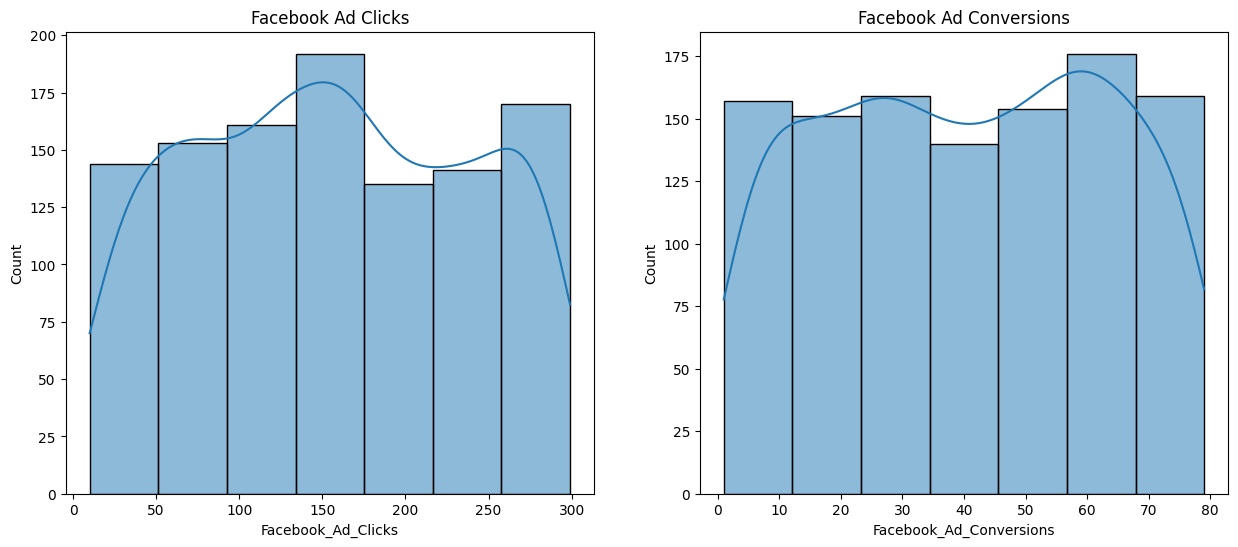

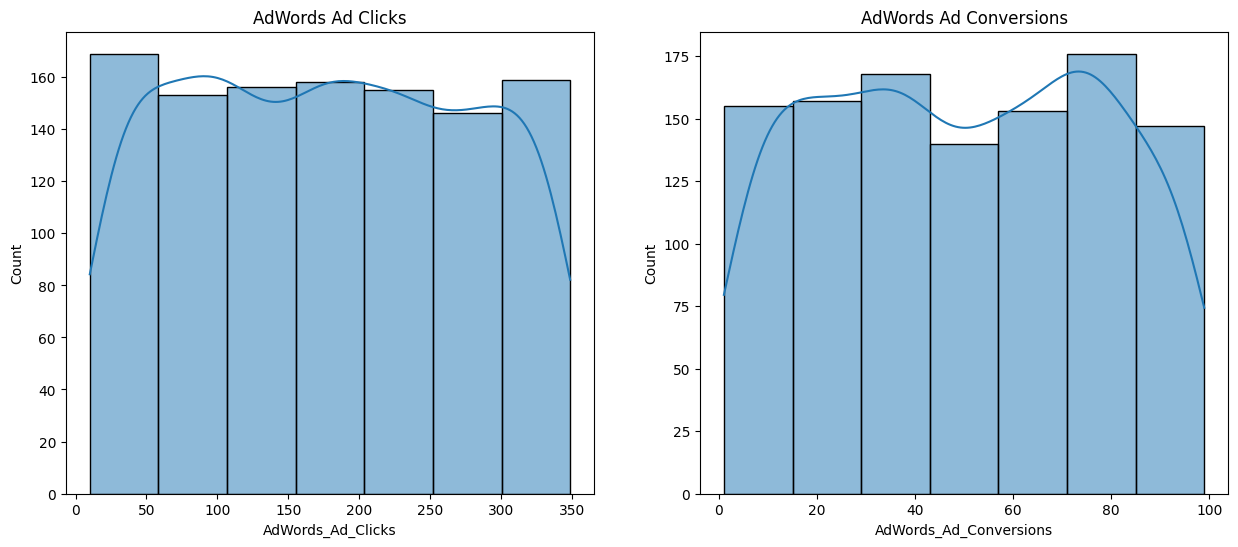

In [42]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('Facebook Ad Clicks')
sns.histplot(df['Facebook_Ad_Clicks'], bins=7, edgecolor='k', kde=True)

plt.subplot(1,2,2)
plt.title('Facebook Ad Conversions')
sns.histplot(df['Facebook_Ad_Conversions'], bins=7, edgecolor='k', kde=True)

plt.savefig('images/facebook_ad_histograms.png', bbox_inches='tight')
plt.show()


plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('AdWords Ad Clicks')
sns.histplot(df['AdWords_Ad_Clicks'], bins=7, edgecolor='k', kde=True)

plt.subplot(1,2,2)
plt.title('AdWords Ad Conversions')
sns.histplot(df['AdWords_Ad_Conversions'], bins=7, edgecolor='k', kde=True)

plt.savefig('images/adwords_ad_histograms.png', bbox_inches='tight')
plt.show()

In [43]:
def create_conversion_category(conversion_col):
    category = []

    for conversion in df[conversion_col]:
        if conversion < 20:
            category.append('less than 20')

        elif 20 <= conversion < 40:
            category.append('20 - 39')

        elif 40 <= conversion < 60:
            category.append('40 - 59')

        else:
            category.append('more than 60')

    return category

df['Facebook_Conversion_Category'] = create_conversion_category('Facebook_Ad_Conversions')

df['AdWords_Conversion_Category'] = create_conversion_category('AdWords_Ad_Conversions')

In [44]:
df[['Facebook_Ad_Conversions',
    'Facebook_Conversion_Category',
    'AdWords_Ad_Conversions',
    'AdWords_Conversion_Category']].head()

,Facebook_Ad_Conversions,Facebook_Conversion_Category,AdWords_Ad_Conversions,AdWords_Conversion_Category
0,71,more than 60,53,40 - 59
1,30,20 - 39,72,more than 60
2,7,less than 20,4,less than 20
3,67,more than 60,91,more than 60
4,65,more than 60,5,less than 20


In [45]:
df['Facebook_Conversion_Category'].value_counts()

Facebook_Conversion_Category
40 - 59         284
20 - 39         279
more than 60    278
less than 20    255
Name: count, dtype: int64

In [46]:
facebook = (
    pd.DataFrame(df['Facebook_Conversion_Category'].value_counts())
    .reset_index()
    .rename(columns={
        'Facebook_Conversion_Category': 'Count',
        'index': 'Category'
    })
)

facebook

,Count,count
0,40 - 59,284
1,20 - 39,279
2,more than 60,278
3,less than 20,255


In [47]:
df['AdWords_Conversion_Category'].value_counts()

AdWords_Conversion_Category
more than 60    445
20 - 39         237
less than 20    210
40 - 59         204
Name: count, dtype: int64

In [48]:
adwords = (
    pd.DataFrame(df['AdWords_Conversion_Category'].value_counts())
    .reset_index()
    .rename(columns={
        'AdWords_Conversion_Category': 'Count',
        'index': 'Category'
    })
)

adwords

,Count,count
0,more than 60,445
1,20 - 39,237
2,less than 20,210
3,40 - 59,204


In [49]:
facebook = df['Facebook_Conversion_Category'].value_counts().reset_index()
facebook.columns = ['Category', 'Facebook_Count']

adwords = df['AdWords_Conversion_Category'].value_counts().reset_index()
adwords.columns = ['Category', 'AdWords_Count']

In [50]:
category_df = pd.merge(
    facebook,
    adwords,
    on='Category',
    how='outer'
).fillna(0)

category_df

,Category,Facebook_Count,AdWords_Count
0,20 - 39,279,237
1,40 - 59,284,204
2,less than 20,255,210
3,more than 60,278,445


In [51]:
category_df = category_df.iloc[[3,1,0,2]]
category_df

,Category,Facebook_Count,AdWords_Count
3,more than 60,278,445
1,40 - 59,284,204
0,20 - 39,279,237
2,less than 20,255,210


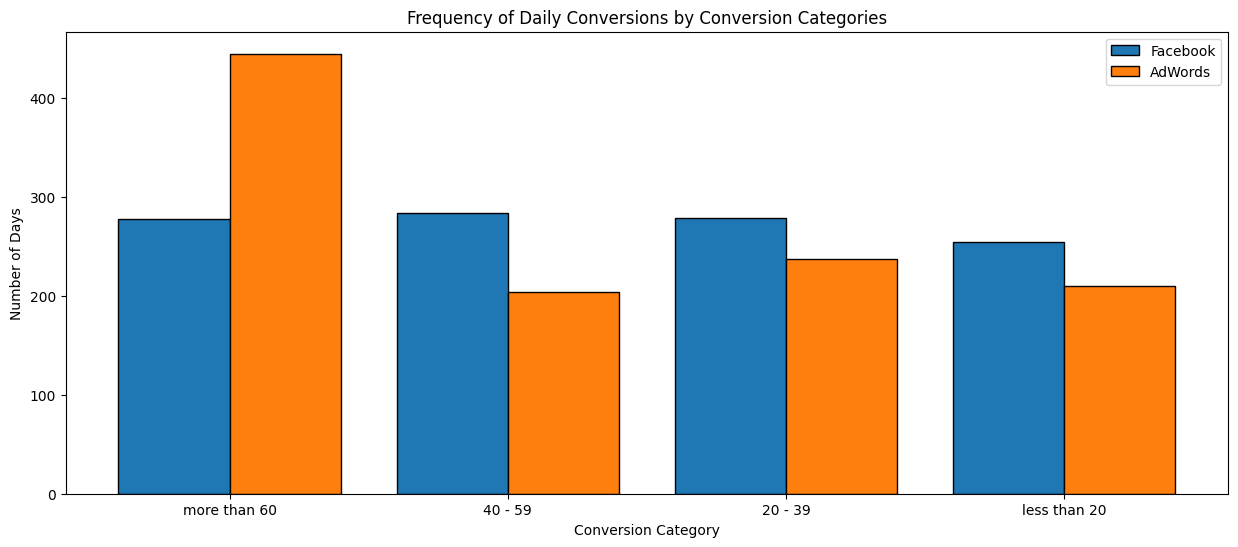

In [52]:
X_axis = np.arange(len(category_df))

plt.figure(figsize=(15,6))

plt.bar(
    X_axis - 0.2,
    category_df['Facebook_Count'],
    0.4,
    label='Facebook',
    edgecolor='k'
)

plt.bar(
    X_axis + 0.2,
    category_df['AdWords_Count'],
    0.4,
    label='AdWords',
    edgecolor='k'
)

plt.xticks(X_axis, category_df['Category'])
plt.xlabel("Conversion Category")
plt.ylabel("Number of Days")
plt.title("Frequency of Daily Conversions by Conversion Categories")
plt.legend()
plt.savefig('images/conversion_category_frequency.png', bbox_inches='tight')

plt.show()

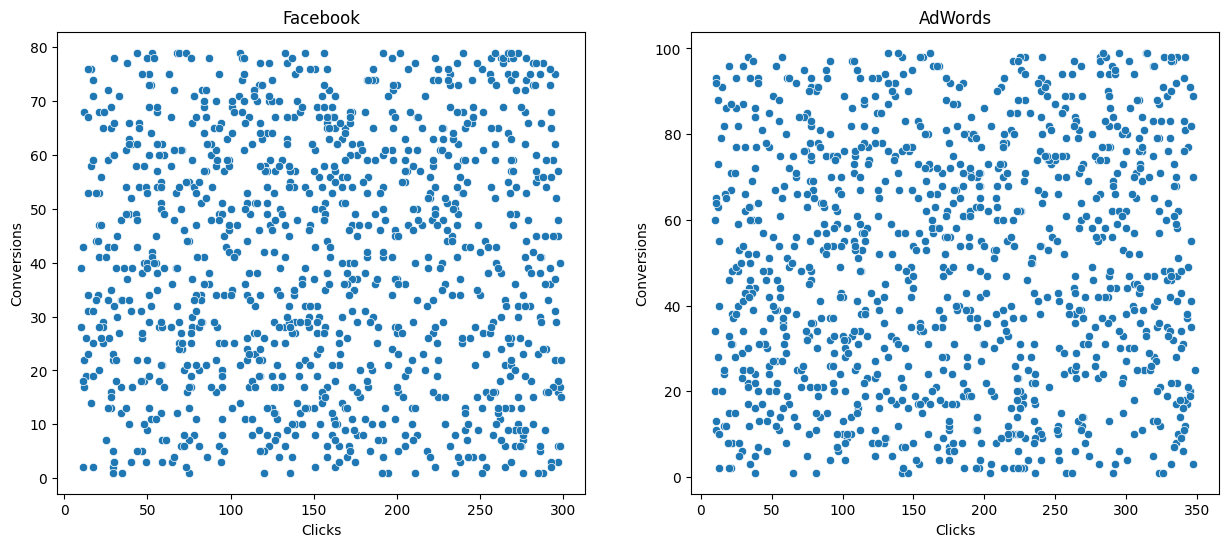

In [53]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title('Facebook')
sns.scatterplot(
    x=df['Facebook_Ad_Clicks'],
    y=df['Facebook_Ad_Conversions']
)
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.subplot(1,2,2)
plt.title('AdWords')
sns.scatterplot(
    x=df['AdWords_Ad_Clicks'],
    y=df['AdWords_Ad_Conversions']
)
plt.xlabel('Clicks')
plt.ylabel('Conversions')

plt.savefig('images/clicks_vs_conversions_scatter.png', bbox_inches='tight')
plt.show()

In [54]:
facebook_corr = df[['Facebook_Ad_Conversions', 'Facebook_Ad_Clicks']].corr()

facebook_corr

,Facebook_Ad_Conversions,Facebook_Ad_Clicks
Facebook_Ad_Conversions,1.000000,0.001809
Facebook_Ad_Clicks,0.001809,1.000000


In [55]:
adwords_corr = df[['AdWords_Ad_Conversions', 'AdWords_Ad_Clicks']].corr()

adwords_corr

,AdWords_Ad_Conversions,AdWords_Ad_Clicks
AdWords_Ad_Conversions,1.000000,0.040314
AdWords_Ad_Clicks,0.040314,1.000000


In [56]:
print('Correlation Coeff\n----------------')

print('Facebook :', round(facebook_corr.values[0,1], 2))
print('AdWords  :', round(adwords_corr.values[0,1], 2))

Correlation Coeff
----------------
Facebook : 0.0
AdWords  : 0.04


In [57]:
print('Mean Conversion\n----------------')

print('Facebook :', round(df['Facebook_Ad_Conversions'].mean(), 2))
print('AdWords  :', round(df['AdWords_Ad_Conversions'].mean(), 2))


t_stats, p_value = st.ttest_ind(
    a=df['Facebook_Ad_Conversions'],
    b=df['AdWords_Ad_Conversions'],
    equal_var=False
)

print('\nT statistic:', t_stats)
print('P-value:', p_value)


# comparing the p-value with significance level of 0.05

if p_value < 0.05:
    print('\nP-value is less than significance value, Reject the null hypothesis')
else:
    print('\nP-value is greater than significance value, Accept the null hypothesis')

Mean Conversion
----------------
Facebook : 40.48
AdWords  : 49.59

T statistic: -8.322173560771411
P-value: 1.538558995382618e-16

P-value is less than significance value, Reject the null hypothesis


In [58]:
# independent variable

X = df[['Facebook_Ad_Clicks']]

# dependent variable

y = df[['Facebook_Ad_Conversions']]

# initializing and fitting Linear Regression model

reg_model = LinearRegression()

reg_model.fit(X, y)

prediction = reg_model.predict(X)

# model evaluation

r2 = r2_score(y, prediction) * 100

mse = mean_squared_error(y, prediction)

print('Accuracy (R2 Score):', round(r2, 2), '%')
print('Mean Squared Error:', round(mse, 2))

Accuracy (R2 Score): 0.0 %
Mean Squared Error: 512.84


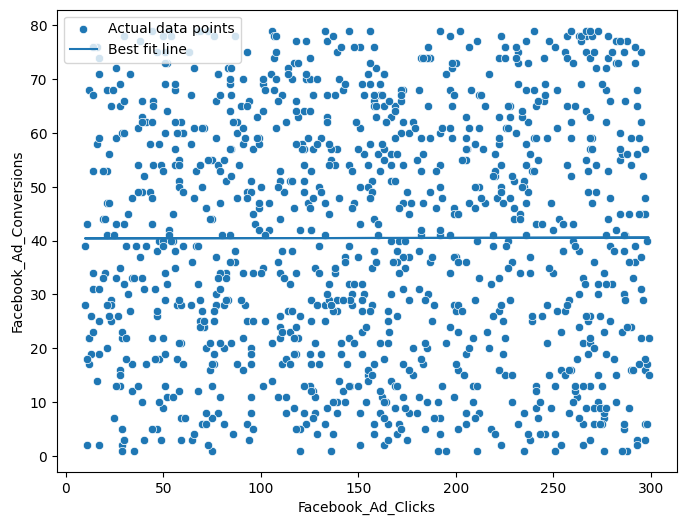

In [59]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Facebook_Ad_Clicks'],
    y=df['Facebook_Ad_Conversions'],
    label='Actual data points'
)

plt.plot(
    df['Facebook_Ad_Clicks'],
    prediction,
    label='Best fit line'
)

plt.legend()
plt.savefig('images/facebook_clicks_vs_conversions_regression.png', bbox_inches='tight')

plt.show()

In [60]:
print(f'For 50 Clicks, Expected Conversion : {round(reg_model.predict([[50]])[0][0], 2)}')

print(f'For 80 Clicks, Expected Conversion : {round(reg_model.predict([[80]])[0][0], 2)}')

For 50 Clicks, Expected Conversion : 40.43
For 80 Clicks, Expected Conversion : 40.44


In [61]:
# extracting month and week day from the date column

df['month'] = df['Date'].dt.month
df['week'] = df['Date'].dt.weekday

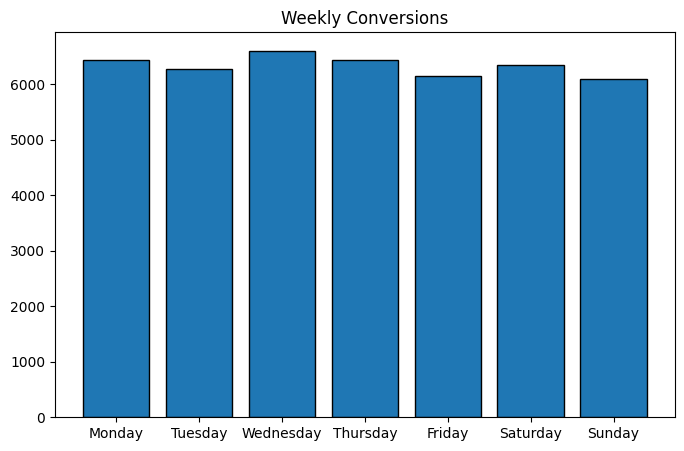

In [62]:
plt.figure(figsize=(8,5))

plt.title('Weekly Conversions')

weekly_conversion = df.groupby('week')[['Facebook_Ad_Conversions']].sum()

week_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.bar(
    week_names,
    weekly_conversion['Facebook_Ad_Conversions'],
    edgecolor='k'
)

plt.savefig('images/weekly_conversions.png', bbox_inches='tight')
plt.show()

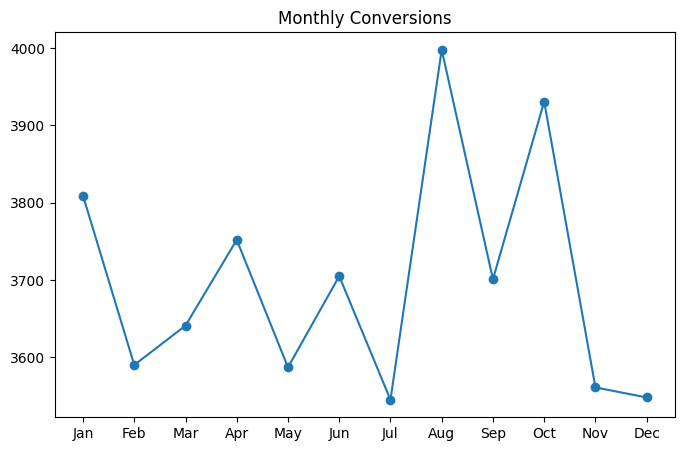

In [63]:
plt.figure(figsize=(8,5))

plt.title('Monthly Conversions')

monthly_conversion = df.groupby('month')[['Facebook_Ad_Conversions']].sum()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.plot(
    month_names,
    monthly_conversion['Facebook_Ad_Conversions'],
    '-o'
)

plt.savefig('images/monthly_conversions.png', bbox_inches='tight')
plt.show()

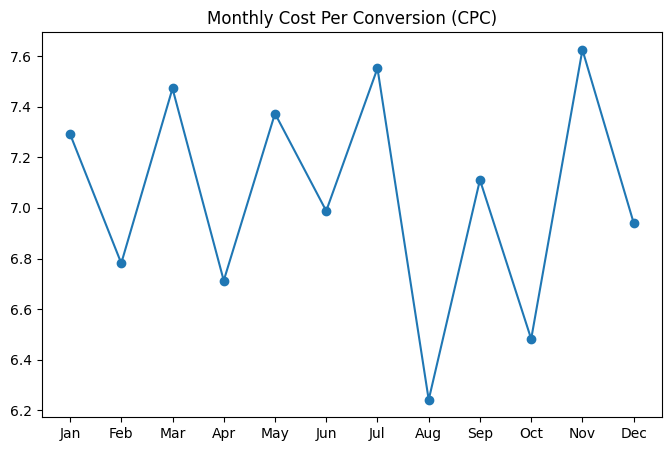

In [64]:
plt.figure(figsize=(8,5))

plt.title('Monthly Cost Per Conversion (CPC)')

monthly_df = df.groupby('month')[['Facebook_Ad_Conversions', 'Cost_Per_Facebook_Ad']].sum()

monthly_df['Cost_Per_Conversion'] = (
    monthly_df['Cost_Per_Facebook_Ad'] /
    monthly_df['Facebook_Ad_Conversions']
)

plt.plot(
    month_names,
    monthly_df['Cost_Per_Conversion'],
    '-o'
)

plt.savefig('images/monthly_cost_per_conversion.png', bbox_inches='tight')
plt.show()

In [65]:
score, p_value, _ = coint(
    df['Cost_Per_Facebook_Ad'],
    df['Facebook_Ad_Conversions']
)

print('Cointegration test score:', score)
print('P-value:', p_value)

if p_value < 0.05:
    print('\nP-value is less than significance value, Reject the null hypothesis')
else:
    print('\nP-value is greater than significance value, Accept the null hypothesis')

Cointegration test score: -31.86675262376291
P-value: 0.0

P-value is less than significance value, Reject the null hypothesis
